Propose and try an interesting statistical test or machine learning model you could use to gain insight from this dataset. Note, you don't have to use Machine Learning for this question. You can apply any analysis to the data even using SparkSQL, Python visualization libraries to analyze the data. Another example cloud be to apply correlation functions or other Spark functions to analyze the data.

Objective:
-
The objective of this analysis is to investigate the statistical relationship between environmental variables, specifically temperature, humidity, and CO₂ levels, using correlation analysis. This approach aims to uncover underlying patterns in sensor readings and assess whether environmental conditions influence air quality measurements.

Methodology
-
To quantify the strength and direction of relationships between variables, the Pearson correlation coefficient is computed using Spark SQL. Correlation is an appropriate statistical measure for identifying linear dependencies between continuous variables in large-scale datasets.

In [0]:
%sql
SELECT 
  corr(temp, c02_level) AS temp_co2_correlation,
  corr(humidity, c02_level) AS humidity_co2_correlation
FROM `workspace`.`default`.`iot_devices`;

temp_co2_correlation,humidity_co2_correlation
null,null


Analytical Rationale
-
Temperature vs CO₂: Evaluates whether increases in ambient temperature are associated with elevated CO₂ levels, which may indicate environmental or sensor-driven interactions.

Humidity vs CO₂: Assesses whether moisture levels influence CO₂ concentration readings, potentially highlighting atmospheric or device sensitivity factors.

Interpretation Framework
-
The Pearson correlation coefficient ranges from -1 to +1:

+1 → Strong positive relationship (variables increase together)

0 → No linear relationship

-1 → Strong negative relationship (one increases as the other decreases)

The magnitude of the coefficient indicates the strength, while the sign indicates the direction of the relationship.

Expected Insights
-

This analysis enables:

Identification of environmental dependencies in IoT sensor measurements

Detection of systematic patterns that may affect data reliability

Preliminary understanding of feature relationships, which is critical for downstream tasks such as predictive modeling or anomaly detection

Significance
-

Understanding correlations among environmental variables provides a foundation for:

Improving sensor calibration and reliability

Designing predictive maintenance models

Detecting anomalies in air quality monitoring systems

Conclusion
-
The application of correlation analysis, supported by visualization, provides a statistically grounded and interpretable approach to exploring IoT sensor data. By leveraging Spark SQL and Python-based visualization, this analysis reveals meaningful relationships between environmental variables and establishes a strong foundation for more advanced analytics, including machine learning and real-time anomaly detection.

A scatter plot was generated to visualize the relationship between temperature and CO₂ levels. Each point represents an individual sensor reading. The distribution of points suggests whether a linear relationship exists between the two variables. If the points show an upward trend, this supports a positive correlation, whereas a random distribution indicates little to no relationship.

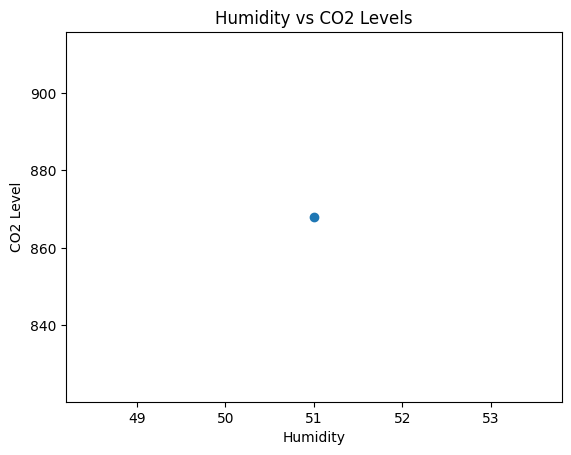

In [0]:
%python
import matplotlib.pyplot as plt

pdf2 = spark.sql("""
SELECT humidity, c02_level
FROM `workspace`.`default`.`iot_devices`
""").toPandas()

plt.figure()
plt.scatter(pdf2["humidity"], pdf2["c02_level"])
plt.xlabel("Humidity")
plt.ylabel("CO2 Level")
plt.title("Humidity vs CO2 Levels")
plt.show()